In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
import math
import os
import os.path
import pickle
import time
import zipfile

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import plotnine as pn
import scipy
import pymc as pm
import pycwt

from shoreshop3_analysis import data, wavelet

In [11]:
input_duck_frf = data.load_frf_single('00001')
input_duck_frf

,time,xFRF,yFRF,latitude,longitude,date
0,1980-10-10 17:45:00,107.839,1.0,33.568228,-85.567133,1980-10-10
1,1981-01-20 19:30:00,96.336,1.0,33.568221,-85.567257,1981-01-20
2,1981-02-04 17:00:00,93.645,1.0,33.568220,-85.567286,1981-02-04
3,1981-02-17 19:20:00,95.056,1.0,33.568220,-85.567271,1981-02-17
4,1981-03-03 16:00:00,102.258,1.0,33.568225,-85.567193,1981-03-03
...,...,...,...,...,...,...
684,2019-09-23 18:27:05,121.974,1.0,33.568236,-85.566981,2019-09-23
685,2019-10-15 18:35:10,119.463,1.0,33.568235,-85.567008,2019-10-15
686,2019-10-25 18:12:58,118.113,1.0,33.568234,-85.567023,2019-10-25
687,2019-11-22 19:32:57,117.331,1.0,33.568234,-85.567031,2019-11-22


In [12]:
input_duck_coastsat = data.load_coastsat_single('0045_0041')
input_duck_coastsat

,date,x
0,1984-04-14 15:08:14,26.5
1,1984-06-17 15:09:24,28.4
2,1984-07-03 15:09:35,29.8
3,1984-09-21 15:11:10,25.9
4,1984-10-07 15:11:10,20.9
...,...,...
587,2025-12-03 15:41:25,42.8
588,2025-12-19 15:41:27,32.4
589,2025-12-27 15:41:18,29.3
590,2026-01-04 15:41:25,33.8


In [13]:
duck_cur = data.load_single_profile_models()
duck_cur

,date,frf1,frf1006,model
0,1980-01-02,95.7000,97.800,CEERD-CHL-Devoe
1,1980-01-03,95.9000,98.300,CEERD-CHL-Devoe
2,1980-01-04,96.0000,98.500,CEERD-CHL-Devoe
3,1980-01-05,95.9000,98.200,CEERD-CHL-Devoe
4,1980-01-06,95.9000,98.400,CEERD-CHL-Devoe
...,...,...,...,...
16065,2023-12-27,109.9425,101.563,UNSW-WRL-Mao
16066,2023-12-28,109.9425,101.563,UNSW-WRL-Mao
16067,2023-12-29,109.9425,101.563,UNSW-WRL-Mao
16068,2023-12-30,109.9425,101.563,UNSW-WRL-Mao


In [14]:
poorly_normalized_models = set(duck_cur[duck_cur['frf1'] < 60]['model'].unique())
poorly_normalized_models

{'CoSMoS-COAST-conv',
 'CoSMoS-COAST-conv_IA',
 'CoSMoS-COAST-dmd',
 'CoSMoS-COAST-dmd_IA'}

In [15]:
duck_cur_clean = duck_cur[~duck_cur['model'].isin(poorly_normalized_models)]

In [19]:
mean_pos = duck_cur_clean.groupby('date').agg(frf1=('frf1', 'mean'), frf1006=('frf1006', 'mean')).reset_index()
mean_pos['date'] = pd.to_datetime(mean_pos['date'])
mean_pos

,date,frf1,frf1006
0,1980-01-02,96.249234,115.210214
1,1980-01-03,96.084769,114.991108
2,1980-01-04,96.039272,114.921351
3,1980-01-05,95.945170,114.566621
4,1980-01-06,95.731484,114.116741
...,...,...,...
16065,2023-12-27,124.699410,106.158125
16066,2023-12-28,124.525464,105.989227
16067,2023-12-29,124.760543,106.291363
16068,2023-12-30,124.623005,106.306081


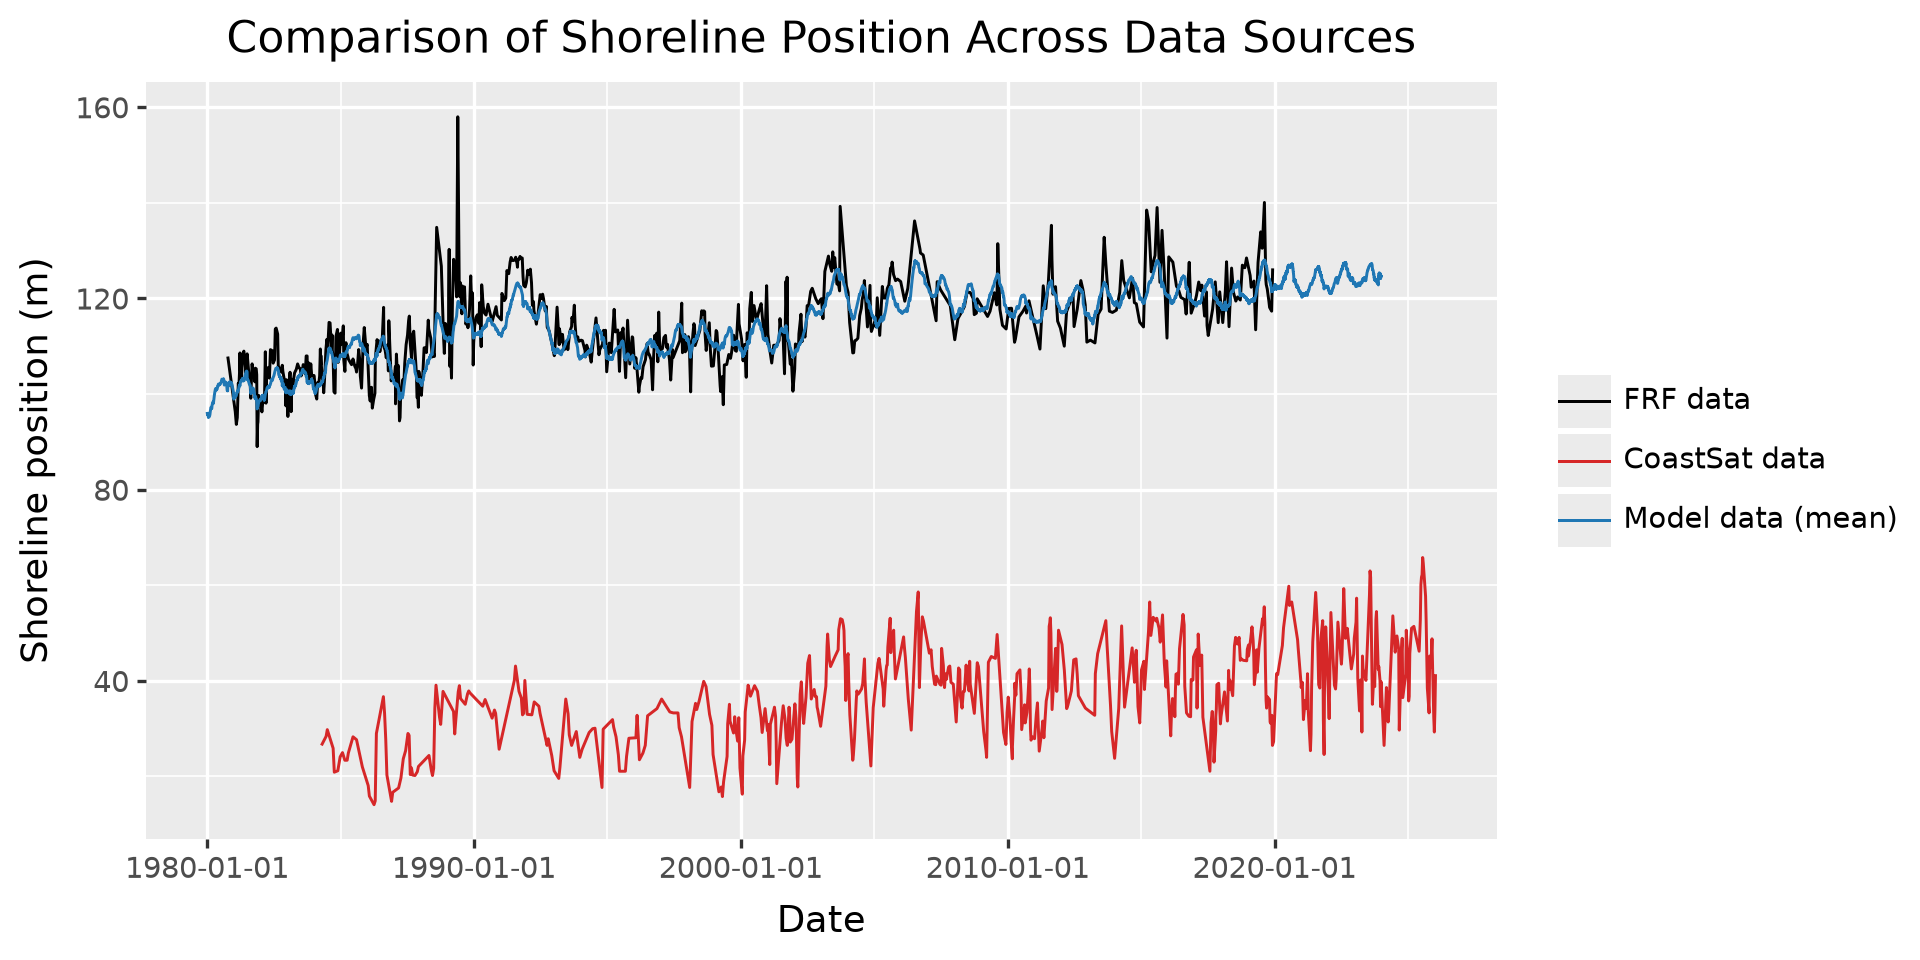

In [20]:
(
    pn.ggplot()
    + pn.geom_line(pn.aes('time', 'xFRF', group=1, color='"FRF data"'), data=input_duck_frf)
    + pn.geom_line(pn.aes('date', 'x', group=1, color='"CoastSat data"'), data=input_duck_coastsat)
    + pn.geom_line(pn.aes('date', 'frf1', color='"Model data (mean)"'), data=mean_pos)
    + pn.scale_color_manual(values={'FRF data': 'k', 'CoastSat data': 'tab:red', 'Model data (mean)': 'tab:blue'})
    # + pn.geom_line(pn.aes('date', 'frf1', group=1), data=duck_cur, color='tab:red')
    + pn.scale_x_date()
    + pn.labs(x='Date', y='Shoreline position (m)', title='Comparison of Shoreline Position Across Data Sources')
    + pn.theme(legend_title=pn.element_blank(), figure_size=(8, 4), dpi=120)
)

In [21]:
duck_cur_clean.groupby('model').agg(first=('date', 'first'), last=('date', 'last'))

,first,last
model,,
CEERD-CHL-Cohn-CSHORE,1980-01-02,2023-12-31
CEERD-CHL-Devoe,1980-01-02,2023-12-31
CEERD-CHL-Holzenthal-GENCADE,1980-01-02,2023-12-31
COCollective,1980-01-02,2023-12-31
CSIRO_nearshore,1982-09-09,2023-12-31
CSIRO_nearshore-smoothed,1982-09-05,2023-12-31
GEOOCEAN,1980-01-02,2023-11-22
GEOOCEAN-cross_eps,1980-01-02,2023-11-22
ICM-TCN,1980-10-17,2023-12-31


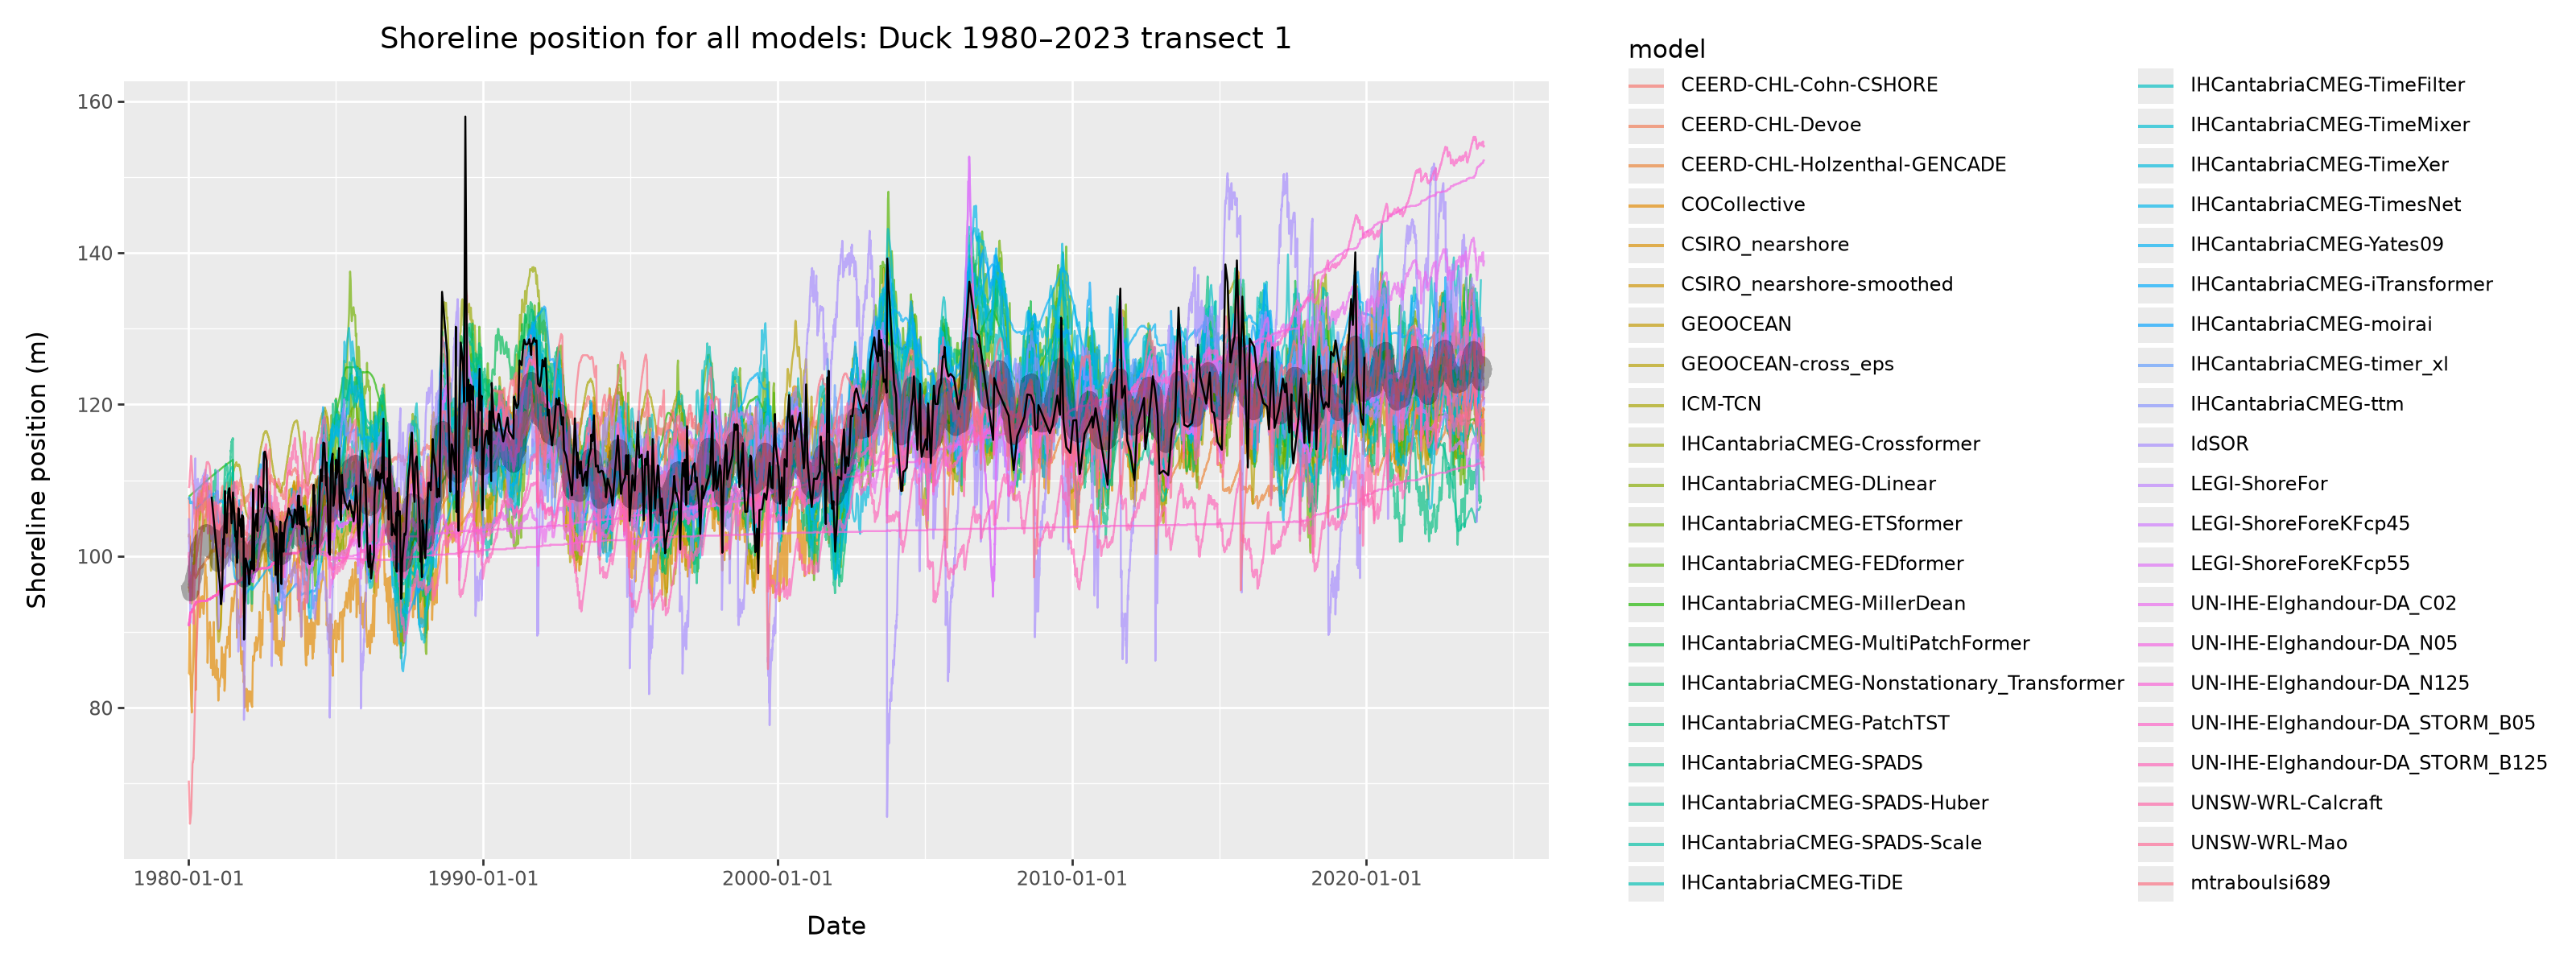

In [23]:

(
    pn.ggplot(duck_cur_clean)
    + pn.geom_line(pn.aes('date', 'frf1', group='model', color='model'), size=0.5, alpha=0.67)
    + pn.geom_line(pn.aes('date', 'frf1', group=1), data=mean_pos, color='k', size=4, alpha=0.3)
    + pn.geom_line(pn.aes('time', 'xFRF', group=1), data=input_duck_frf, color='k')
    + pn.scale_x_date()
    + pn.labs(x='Date', y='Shoreline position (m)', title='Shoreline position for all models: Duck 1980–2023 transect 1')
    + pn.theme(legend_position='right', figure_size=(16, 6))
    + pn.guides(color=pn.guide_legend(ncol=2))
    
)


CWT took 95.603 ms
1596.224 ms


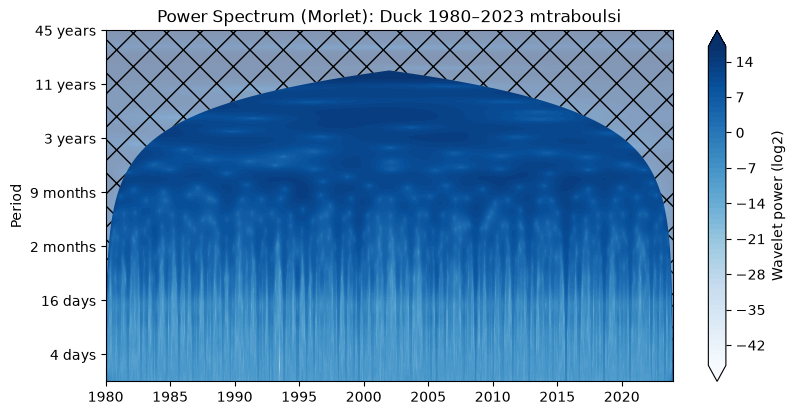

In [24]:
start = time.perf_counter_ns()

selected_model = duck_cur[duck_cur['model'] == 'mtraboulsi689']

dt = 1.0
wave_result = wavelet.CWT(selected_model['date'], selected_model['frf1'].values, dt=dt, dj=1/12, s0=-1, J=-1, wavelet='morlet', freqs=None)

fig = wave_result.plot(title='Power Spectrum (Morlet): Duck 1980–2023 mtraboulsi')
#fig.set_size_inches(12, 6)
#fig.savefig('../figures/mtraboulsi-cur.png', dpi=180)

elapsed = time.perf_counter_ns() - start
print(f'{elapsed/1e6:.3f} ms')

fig

In [30]:
interp_dt = input_duck_frf['time'].diff().median().days
input_duck_frf_interp = wavelet.time_regularize(input_duck_frf, 'xFRF', interp_dt)
input_duck_frf_interp

,time,xFRF,date
0,1980-10-10 17:45:00,107.839000,1980-10-10
1,1980-10-26 17:45:00,106.034608,1980-10-26
2,1980-11-11 17:45:00,104.230216,1980-11-11
3,1980-11-27 17:45:00,102.425824,1980-11-27
4,1980-12-13 17:45:00,100.621431,1980-12-13
...,...,...,...
889,2019-09-20 17:45:00,122.170500,2019-09-20
890,2019-10-06 17:45:00,120.490227,2019-10-06
891,2019-10-22 17:45:00,118.518000,2019-10-22
892,2019-11-07 17:45:00,117.749929,2019-11-07


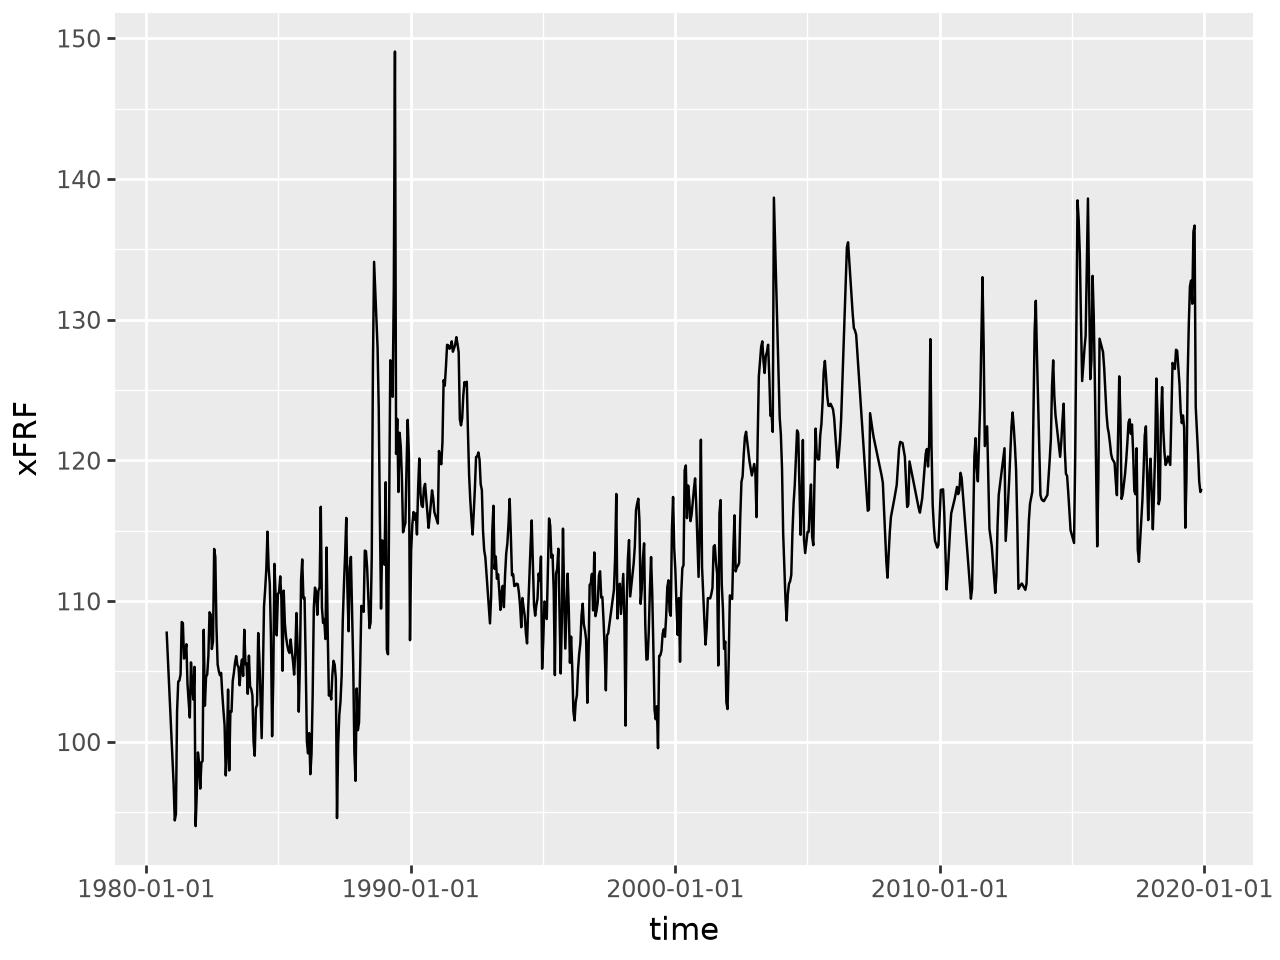

In [31]:
pn.ggplot(input_duck_frf_interp) + pn.geom_line(pn.aes('time', 'xFRF', group=1)) + pn.scale_x_date()

CWT took 19.804 ms


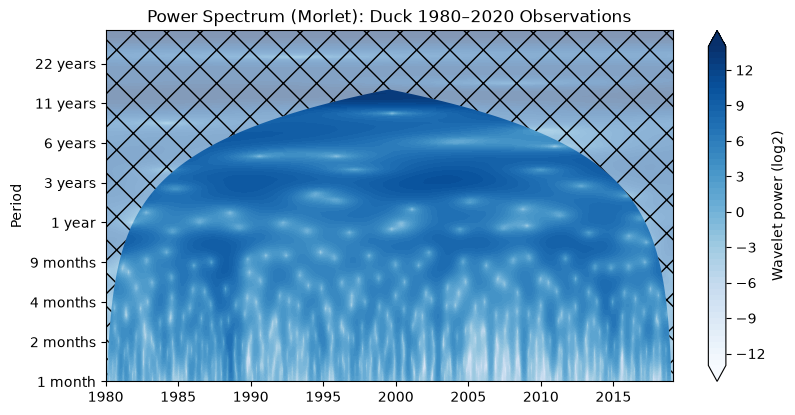

In [32]:
obs_wavelet = wavelet.CWT(input_duck_frf_interp['date'], input_duck_frf_interp['xFRF'].values, dt=interp_dt, dj=1/12, s0=-1, J=-1, wavelet='morlet', freqs=None)

obs_fig = obs_wavelet.plot(title='Power Spectrum (Morlet): Duck 1980–2020 Observations')

#obs_fig.set_size_inches(12, 6)
obs_fig

In [33]:
comparison_df = input_duck_frf_interp.merge(selected_model, on='date', how='left')
comparison_df

,time,xFRF,date,frf1,frf1006,model
0,1980-10-10 17:45:00,107.839000,1980-10-10,103.0,112.4,mtraboulsi689
1,1980-10-26 17:45:00,106.034608,1980-10-26,104.1,113.2,mtraboulsi689
2,1980-11-11 17:45:00,104.230216,1980-11-11,104.1,111.9,mtraboulsi689
3,1980-11-27 17:45:00,102.425824,1980-11-27,105.7,114.0,mtraboulsi689
4,1980-12-13 17:45:00,100.621431,1980-12-13,106.0,112.2,mtraboulsi689
...,...,...,...,...,...,...
889,2019-09-20 17:45:00,122.170500,2019-09-20,124.6,130.3,mtraboulsi689
890,2019-10-06 17:45:00,120.490227,2019-10-06,120.0,125.3,mtraboulsi689
891,2019-10-22 17:45:00,118.518000,2019-10-22,122.3,125.9,mtraboulsi689
892,2019-11-07 17:45:00,117.749929,2019-11-07,123.5,125.7,mtraboulsi689


In [34]:
start = time.perf_counter_ns()
wct = wavelet.WCT(
    comparison_df['date'],
    comparison_df['xFRF'].values,
    comparison_df['frf1'].values,
    dt=interp_dt,
    dj=1/12,
    s0=-1,
    J=-1,
    sig=True,
    significance_level=0.95,
    wavelet='morlet',
    normalize=True,
    mc_count=20,
    cache=False,
)
elapsed = time.perf_counter_ns() - start
print(f'{elapsed/1e6:.3f} ms')
# took 7 minutes, 16 seconds with sig=True, mc_count=300; 140 seconds with mc_count=100, 30 seconds with mc_count=20

Calculating wavelet coherence significance


100%|██████████| 20/20 [00:30<00:00,  1.51s/it]

30360.314 ms
float64


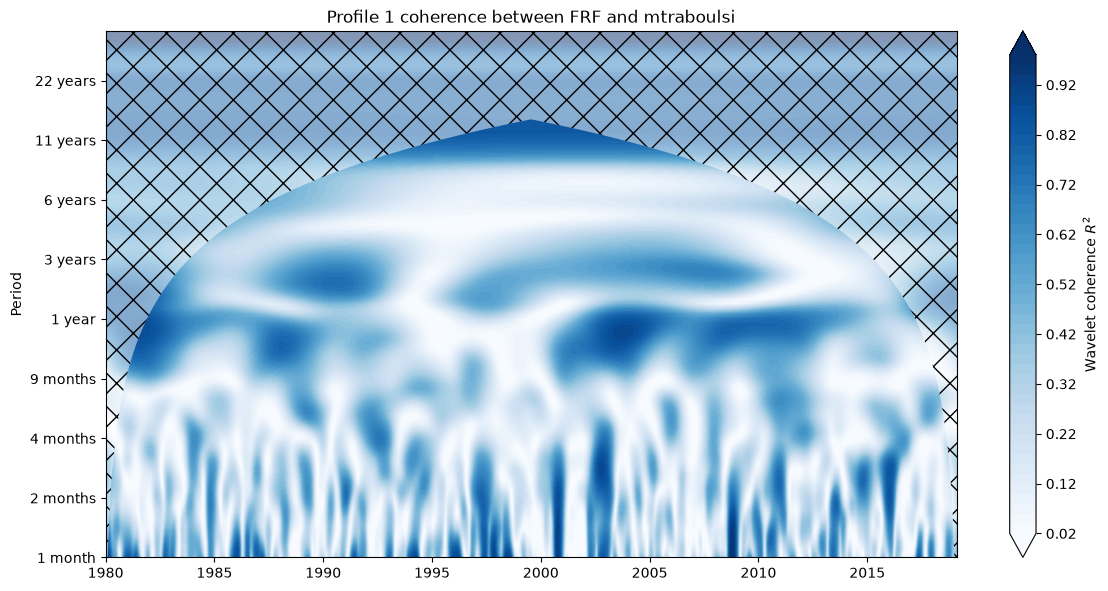

In [35]:
wct_fig = wct.plot(title='Profile 1 coherence between FRF and mtraboulsi')
wct_fig.set_size_inches(12, 6)
#wct_fig.savefig('../figures/wct.png', dpi=180)
wct_fig

In [36]:
print('wct:', wct._wct.shape, wct._wct.dtype)
print('awct:', wct._awct.shape, wct._awct.dtype)
print('coi:', wct._coi.shape, wct._coi.dtype)
print('freq:', wct._freq.shape, wct._freq.dtype)
print('sig:', wct._sig.shape, wct._sig.dtype)
# plt.close('all')

wct: (107, 894) float64
awct: (107, 894) float64
coi: (894,) float64
freq: (107,) float64
sig: (107,) float64


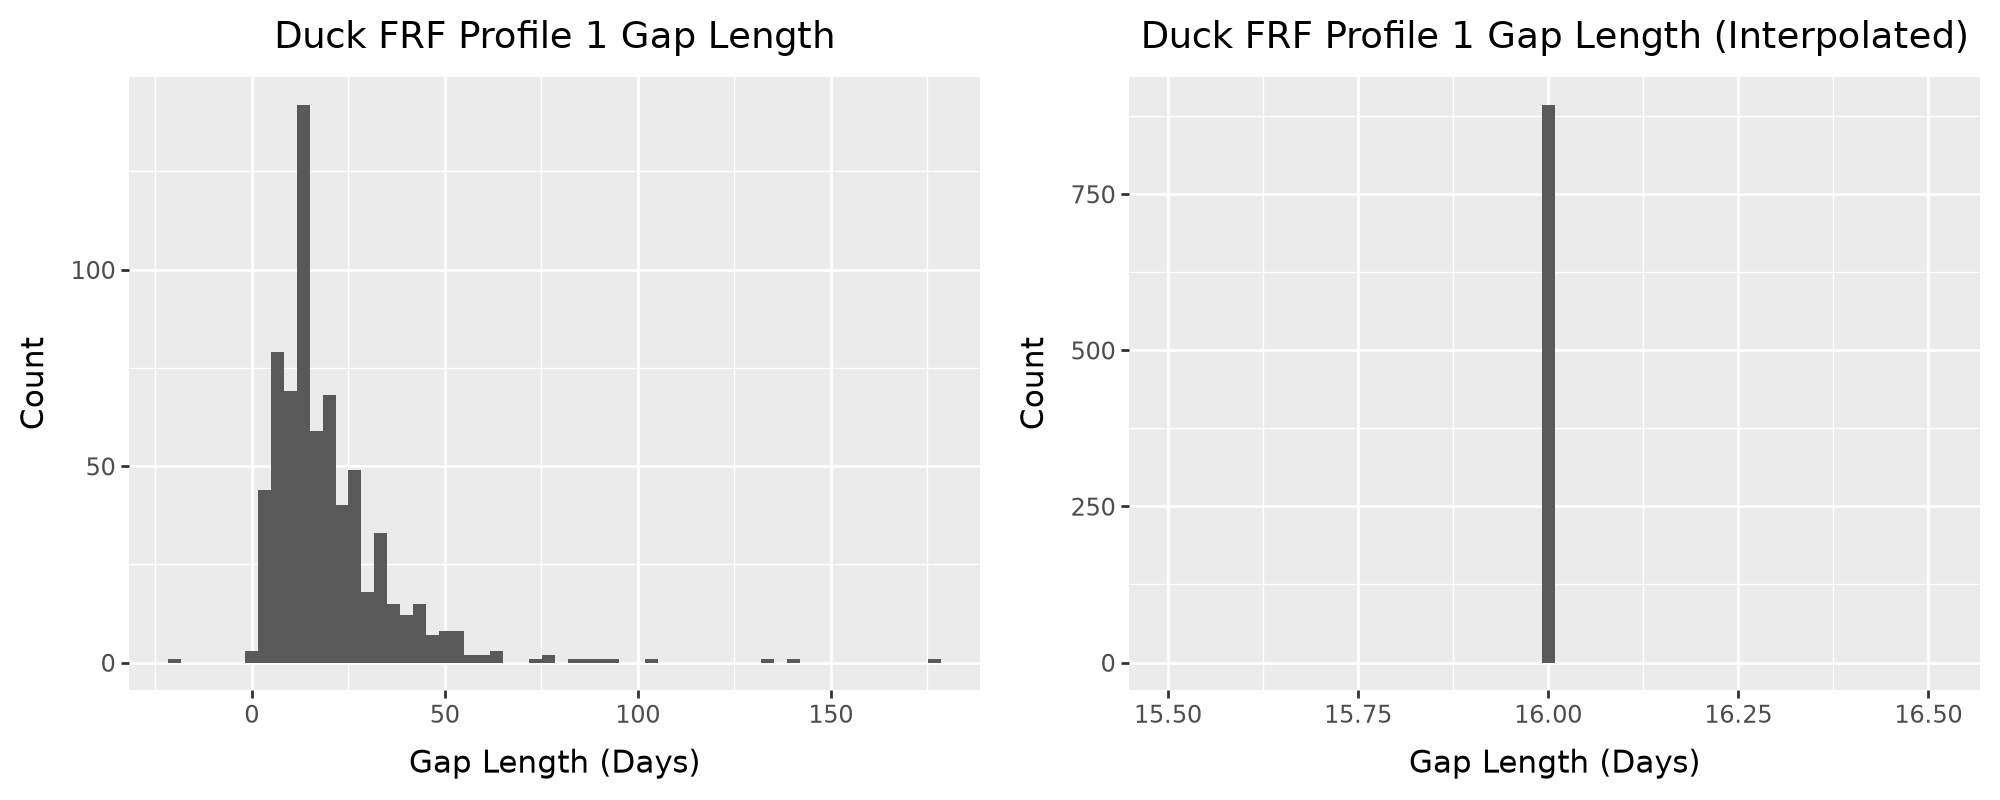

In [38]:
((
    pn.ggplot(pd.to_datetime(input_duck_frf['time']).diff().apply(lambda x: x.days).reset_index().dropna())
    + pn.geom_histogram(pn.aes('time'), bins=60)
    + pn.labs(x='Gap Length (Days)', y='Count', title='Duck FRF Profile 1 Gap Length')
) | (
    pn.ggplot(pd.to_datetime(input_duck_frf_interp['time']).diff().apply(lambda x: x.days).reset_index().dropna())
    + pn.geom_histogram(pn.aes('time'), bins=60)
    + pn.labs(x='Gap Length (Days)', y='Count', title='Duck FRF Profile 1 Gap Length (Interpolated)')
)) & pn.theme(figure_size=(10, 4))